In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

1. Load the dataset


In [3]:

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


Preprocess the data

In [4]:
# Normalize pixel values to range 0 to 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

print("Flattened x_train shape:", x_train.shape)
print("Flattened x_test shape:", x_test.shape)

Flattened x_train shape: (60000, 784)
Flattened x_test shape: (10000, 784)


Build the MLP model

In [5]:
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train the model

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9189 - loss: 0.2805 - val_accuracy: 0.9561 - val_loss: 0.1525
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9632 - loss: 0.1247 - val_accuracy: 0.9657 - val_loss: 0.1156
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0850 - val_accuracy: 0.9710 - val_loss: 0.1005
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9814 - loss: 0.0630 - val_accuracy: 0.9698 - val_loss: 0.0977
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9848 - loss: 0.0492 - val_accuracy: 0.9727 - val_loss: 0.0905
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9887 - loss: 0.0370 - val_accuracy: 0.9746 - val_loss: 0.0904
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9909 - loss: 0.0308 - val_accuracy: 0.9718 - val_loss: 0.0956
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9925 - loss: 0.0241 -

Evaluate on test set

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0934
Test Loss: 0.09344015270471573
Test Accuracy: 0.9736999869346619


Plot accuracy over epochs

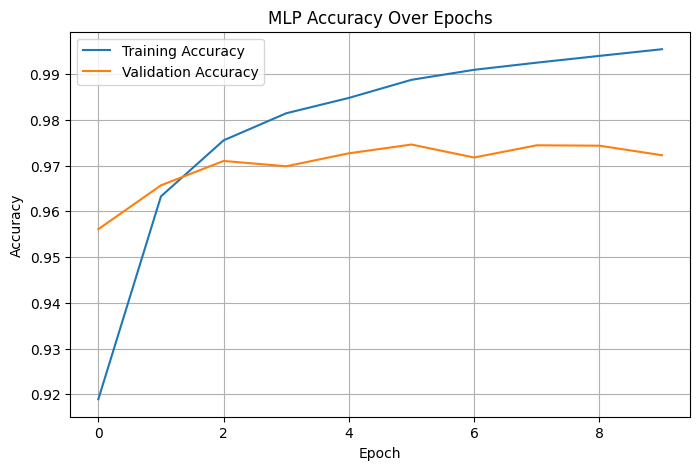

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MLP Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Plot loss over epochs

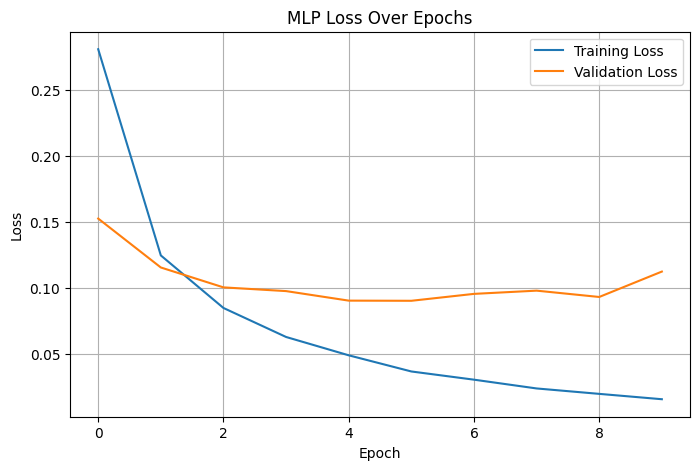

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MLP Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


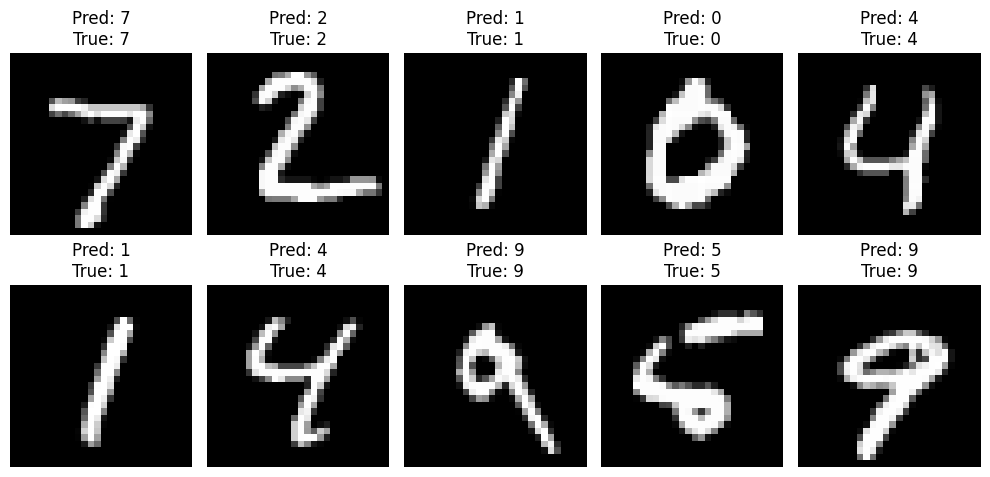

In [12]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Reshape back to 28x28 for display
x_test_images = x_test.reshape(-1, 28, 28)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_images[i], cmap="gray")
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Part A Write Up



I used the MNIST handwritten digit dataset and built a simple multilayer perceptron (MLP) in Keras. The model used one hidden Dense layer with 128 neurons and ReLU activation, followed by a 10 class softmax output layer.

The images were normalized and flattened from 28x28 pixels into 784-length input vectors before training. The model was compiled with the Adam optimizer and sparse categorical crossentropy loss function.

After training for 10 epochs, the model performed well on the test set with a high classification accuracy. The training and validation graphs show that accuracy improved steadily over time, while validation loss stayed relatively stable with a slight increase near the end, suggesting mild overfitting. Overall, the MLP was effective for classifying handwritten digits in the MNIST dataset.

Part B: Convolutional Neural Network (CNN)

Cell Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Load Fashion MNIST

In [14]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


Preprocess for CNN

In [15]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("CNN x_train shape:", x_train.shape)
print("CNN x_test shape:", x_test.shape)

CNN x_train shape: (60000, 28, 28, 1)
CNN x_test shape: (10000, 28, 28, 1)


Class Names

In [17]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

Build CNN

In [18]:
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Part B compile

In [20]:
model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train the model

In [21]:
history_cnn = model_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.8519 - loss: 0.4204 - val_accuracy: 0.8827 - val_loss: 0.3298
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8980 - loss: 0.2861 - val_accuracy: 0.8903 - val_loss: 0.3037
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9102 - loss: 0.2443 - val_accuracy: 0.9055 - val_loss: 0.2621
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9210 - loss: 0.2143 - val_accuracy: 0.9032 - val_loss: 0.2697
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9301 - loss: 0.1907 - val_accuracy: 0.9058 - val_loss: 0.2592
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - accuracy: 0.9377 - loss: 0.1700 - val_accuracy: 0.9059 - val_loss: 0.2710
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9452 - loss: 0.1496 - val_accuracy: 0.9110 - val_loss: 0.2611
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9506 -

Evaluate

In [22]:
test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(x_test, y_test)

print("CNN Test Loss:", test_loss_cnn)
print("CNN Test Accuracy:", test_accuracy_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9057 - loss: 0.3089
CNN Test Loss: 0.3088846802711487
CNN Test Accuracy: 0.9057000279426575


Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


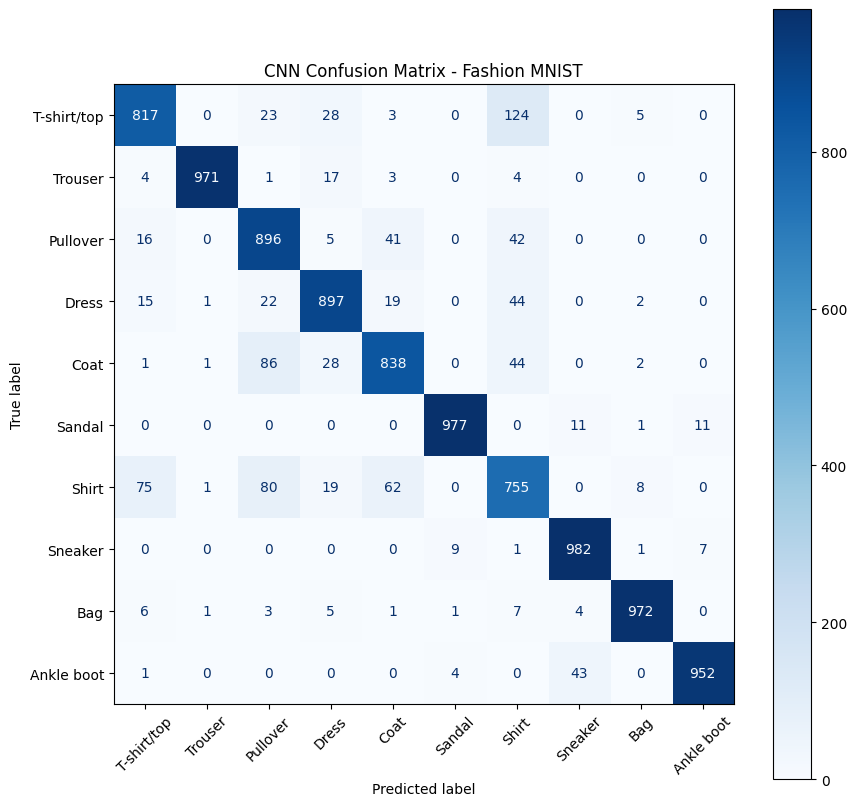

In [23]:
y_pred_probs = model_cnn.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("CNN Confusion Matrix - Fashion MNIST")
plt.show()

Correct Predictions

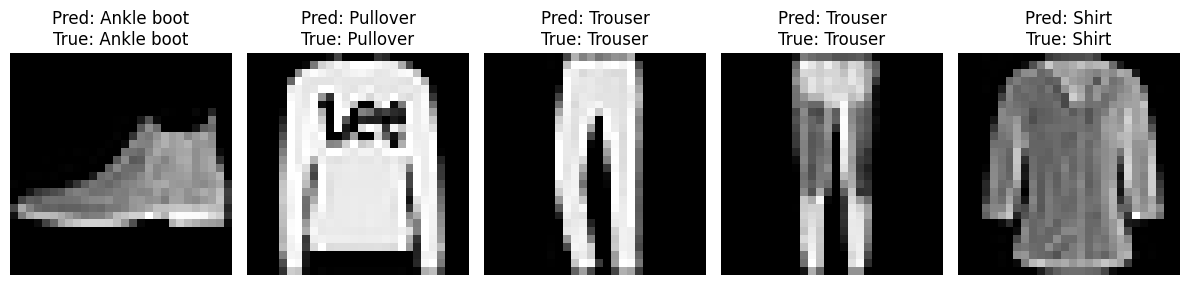

In [24]:
correct_indices = np.where(y_pred == y_test)[0][:5]

plt.figure(figsize=(12, 4))
for i, idx in enumerate(correct_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_test[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Incorrect Predictions

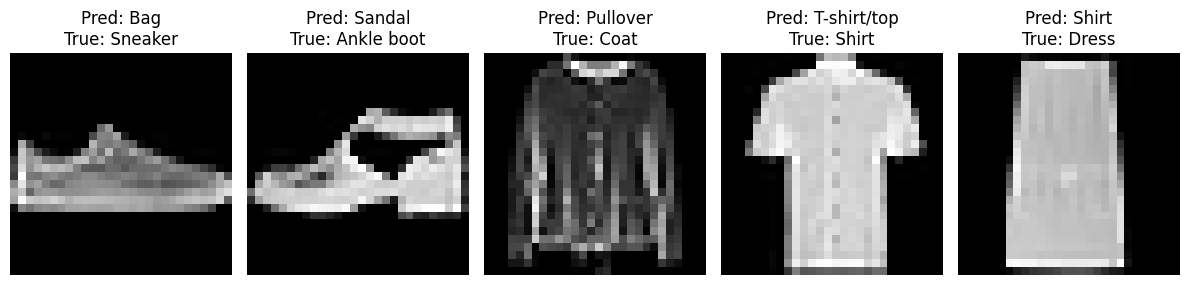

In [25]:
incorrect_indices = np.where(y_pred != y_test)[0][:5]

plt.figure(figsize=(12, 4))
for i, idx in enumerate(incorrect_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_test[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Part B Write Up

I used the Fashion MNIST dataset and built a convolutional neural network (CNN) in Keras. The model included one convolutional layer, one max pooling layer, a flatten layer, one dense hidden layer, and a softmax output layer.

The images were normalized and reshaped to include a channel dimension so that they could be processed correctly by the CNN. The model was trained for 10 epochs using the Adam optimizer and sparse categorical crossentropy loss.

After training, the CNN achieved a test accuracy of approximately 90.57%. A confusion matrix was generated to examine classification performance across the different clothing categories. The model performed well overall, but some misclassifications occurred between visually similar items such as shirts, T-shirts/tops, pullovers, and coats.

A few correctly classified and incorrectly classified examples were also displayed. These examples helped show that the CNN was generally effective, while also revealing which image types were harder for the model to distinguish.

Part C: Recurrent Neural Network (RNN/LSTM)

Imports

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Load IMDB dataset

In [27]:
max_features = 10000  # only keep top 10,000 most frequent words
maxlen = 200          # cut reviews after 200 words

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples: 25000


Pad Sequences

In [28]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (25000, 200)
x_test shape: (25000, 200)


Build LSTM Model

In [29]:
model_rnn = keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=64, input_length=maxlen),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid")
])

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [31]:
model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [32]:
history_rnn = model_rnn.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 131ms/step - accuracy: 0.7861 - loss: 0.4497 - val_accuracy: 0.8418 - val_loss: 0.3953
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.8920 - loss: 0.2701 - val_accuracy: 0.8596 - val_loss: 0.3390
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 116ms/step - accuracy: 0.9293 - loss: 0.1879 - val_accuracy: 0.8658 - val_loss: 0.3237
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 129ms/step - accuracy: 0.9497 - loss: 0.1396 - val_accuracy: 0.8430 - val_loss: 0.4074
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 126ms/step - accuracy: 0.9643 - loss: 0.1008 - val_accuracy: 0.8562 - val_loss: 0.4010


Evaluate Model

In [33]:
test_loss_rnn, test_accuracy_rnn = model_rnn.evaluate(x_test, y_test)

print("RNN Test Loss:", test_loss_rnn)
print("RNN Test Accuracy:", test_accuracy_rnn)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8507 - loss: 0.4309
RNN Test Loss: 0.43092331290245056
RNN Test Accuracy: 0.8506799936294556


Plot Accuracy

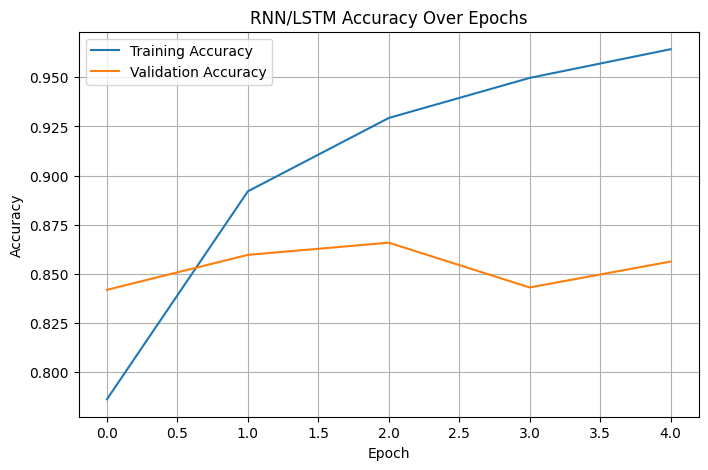

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("RNN/LSTM Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Plot Loss

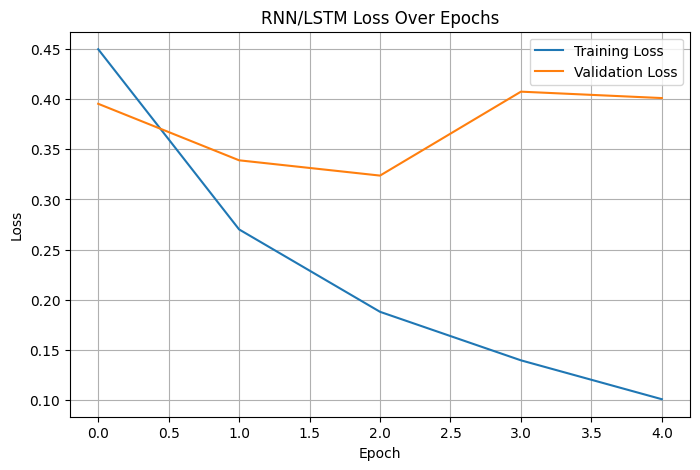

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.title("RNN/LSTM Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Part C Write Up

 I used the IMDB movie review dataset and built a recurrent neural network using an LSTM layer in Keras. This model was used for binary sentiment classification, where the goal was to predict whether a review was positive or negative.

The text data was limited to the 10,000 most frequent words, and each review was padded to a fixed length of 200 words so that the model could process each sequence consistently. The architecture included an embedding layer, one LSTM layer, and a sigmoid output layer.

After training, the model achieved a test accuracy of approximately 85.07%. The accuracy and loss graphs showed that the training accuracy continued to improve across epochs, while validation accuracy improved more slowly and validation loss began to increase after the early epochs. This suggests that the model began to overfit the training data somewhat. Overall, the LSTM still performed well and demonstrated how recurrent neural networks can be used for sequence-based tasks such as sentiment analysis.
Sent from my iPhone

# Part E: Reflection

## Which architecture was most effective for its task?

The CNN was the most effective architecture for its task because convolutional layers are designed to detect patterns in image data, such as edges, textures, and shapes. This made it a better fit for Fashion MNIST than a basic MLP. The MLP also performed very well on MNIST, but it worked with flattened image data and did not preserve spatial relationships the way the CNN did. The LSTM was effective for text sentiment classification, but it showed more overfitting and was more difficult to train than the image models.

## What challenges did you face during training or implementation?

One challenge was preprocessing the data differently for each architecture. The MLP required flattened image vectors, the CNN required image tensors with channel dimensions, and the LSTM required padded text sequences. Another challenge was overfitting, especially in the LSTM model, where training accuracy continued to increase while validation performance became less stable. It was also important to interpret the accuracy and loss graphs carefully so I could understand model behavior over time.

## How do you see these models being used in real-world applications?

MLPs can be used for basic classification tasks and structured data problems. CNNs are widely used in computer vision applications such as image classification, facial recognition, medical imaging, and object detection. RNNs and LSTMs are useful for sequence data such as sentiment analysis, text generation, speech recognition, and time series forecasting. These architectures show how different neural network designs are better suited for different types of data and tasks.

